In [1]:
from bolero.tl.model.mc.dataset import mCplusATACDataset

import pyBigWig
import pandas as pd
import numpy as np
import pysam

from bolero import init

init(num_cpus=32, object_store_memory_gb=100)

2024-08-16 16:18:02,801	INFO worker.py:1771 -- Started a local Ray instance.


In [2]:
data_dir = '/large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/ExampleALLCDataset'

#region_bed_path = f'/large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/bed/MajorTypeDMR.2500.bed'
region_bed_path = f'/large_experiments/zhoulab/zhoujt/project/seqmodel/240804_region_mc/train_bed/ASC.bed'

atac_bw_path = "/large_experiments/zhoulab/hanliu/wmb/Li2023Science/old_annot/bigwig/ASC.bw"
mc_allc_path = '/large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/allc/ASC_0.CGN-Merge.allc.tsv.gz'

In [3]:
mcatac_dataset = mCplusATACDataset(dataset_path=data_dir, genome="hg38", prefix="allc")

mcatac_dataset.train()

File shuffle is disabled!!!
Loading genome DNA one-hot encoding...


In [4]:
mcatac_dataset.get_default_config()

{'dataset_path': 'REQUIRED',
 'prefix': 'REQUIRED',
 'genome': 'REQUIRED',
 'max_jitter': 128,
 'dna_length': 1840,
 'signal_length': 1000,
 'min_cov': 50,
 'max_cov': 100000,
 'low_cov_ratio': 0.1,
 'batch_size': 64,
 'shuffle_files': False,
 'read_parquet_kwargs': None,
 'bigwig_paths': None}

In [4]:
loader1 = mcatac_dataset.get_dataloader(
    chroms=["chr1"], region_bed_path=region_bed_path, n_batches=300, as_torch=False
)

for batch in loader1:
    pass

for k, v in batch.items():
    print(k, v.dtype, v.shape)
del loader1

Get dataloader with train mode


2024-08-14 14:07:50,821	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-14_14-07-39_459566_1128185/logs/ray-data
2024-08-14 14:07:50,822	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> TaskPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(CropLastAxisWithJitter)->MapBatches(ReverseComplement)] -> LimitOperator[limit=19264]


Created remote one-hot object at ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000001e1f505)
Data loader kwargs {'prefetch_batches': 3, 'local_shuffle_buffer_size': 2000, 'drop_last': True, 'batch_size': 64}
region object (64,)
dna_one_hot float32 (64, 4, 1840)
allc_mc float32 (64, 3, 1000)
allc_cov float32 (64, 3, 1000)
allc_mc_frac float32 (64, 3, 1000)
atac_bw_values float32 (64, 1, 1000)
jitter float32 (64, 1)


In [6]:
row_id = 0

In [7]:
batch_value = batch['atac_bw_values'][row_id].ravel()

In [8]:
batch_value

array([0.       , 0.6931472, 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 1.0986123, 0.       , 0.       , 

In [20]:
chrom, coords = batch['region'][row_id].split(':')
start, end = map(int, coords.split('-'))
jitter = batch['jitter'][row_id][0]
chrom, start, end, jitter

('chr1', 188583277, 188585617, 62.0)

In [21]:
_input_center = (start + end) // 2
_output_radius = 500
start = _input_center - _output_radius + jitter
end = start + 1000
chrom, start, end

('chr1', 188584009.0, 188585009.0)

In [12]:
with pyBigWig.open(atac_bw_path) as bw:
    data = np.nan_to_num(bw.values(chrom, int(start), int(end), numpy=True))

In [13]:
data

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [24]:
with pysam.TabixFile(mc_allc_path) as allc:
    data = []
    for row in allc.fetch(chrom, start, end):
        print(start, end)
        data.append(row.strip().split('\t'))
region_allc_raw = pd.DataFrame(data)

188584009.0 188585009.0
188584009.0 188585009.0
188584009.0 188585009.0
188584009.0 188585009.0


[W::hts_idx_load3] The index file is older than the data file: /large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/allc/ASC_0.CGN-Merge.allc.tsv.gz.tbi


In [23]:
region_allc_raw

,0,1,2,3,4,5,6
0,chr1,188584110,+,CGT,26,30,1
1,chr1,188584444,+,CGC,8,16,1
2,chr1,188584450,+,CGG,6,16,1
3,chr1,188584778,+,CGA,12,15,1


In [19]:
mc_value = batch["allc_mc_frac"][0,0,:]
# return index where mc_value is not 0
mc_index = np.where(mc_value != 0)[0]
mc_index

array([231, 559, 565, 899])

In [5]:
compressed_bytes_to_tensor_concurrency = (1, 4)
generate_pseudobulk_concurrency = (1, 16)
generate_regions_concurrency = (1, 4)

In [6]:
data = mcatac_dataset._read_parquet(chroms='chr1')
data = mcatac_dataset._filter_meta_region_length(dataset=data)
data = mcatac_dataset._compressed_bytes_to_tensor(
    dataset=data,
    concurrency=compressed_bytes_to_tensor_concurrency,
)
region_bed_path = f'/large_experiments/zhoulab/zhoujt/project/seqmodel/240804_region_mc/train_bed/ASC.bed'
standard_length = max(mcatac_dataset.dna_length , mcatac_dataset.signal_length) + 500
region_bed = mcatac_dataset.standard_region_length(region_bed_path, standard_length)
data = mcatac_dataset._generate_regions(
                dataset=data,
                bed=region_bed,
                action_keys=["allc_mc", "allc_cov"],
                max_regions=None,
                concurrency=generate_regions_concurrency,
            )
def _cov_func(data):
        return data.sum(-1).mean(-1)

data = mcatac_dataset._get_dna_one_hot(
    dataset=data,
    concurrency=1,
)
mcatac_dataset.train() 
data.schema()

2024-08-15 22:12:54,426	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-15_22-12-42_113691_4137831/logs/ray-data
2024-08-15 22:12:54,427	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> LimitOperator[limit=1]


Created remote one-hot object at ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000001e1f505)


Column       Type
------       ----
region       string
allc_mc      numpy.ndarray(shape=(3, 2340), dtype=float)
allc_cov     numpy.ndarray(shape=(3, 2340), dtype=float)
dna_one_hot  numpy.ndarray(shape=(4, 2340), dtype=float)

In [7]:
dataset = mcatac_dataset._get_mc_frac(data)
dataset.schema()

2024-08-15 22:13:03,099	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-15_22-12-42_113691_4137831/logs/ray-data
2024-08-15 22:13:03,100	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(_mc_frac)] -> LimitOperator[limit=1]


Column        Type
------        ----
region        string
allc_mc       numpy.ndarray(shape=(3, 2340), dtype=float)
allc_cov      numpy.ndarray(shape=(3, 2340), dtype=float)
dna_one_hot   numpy.ndarray(shape=(4, 2340), dtype=float)
allc_mc_frac  numpy.ndarray(shape=(3, 2340), dtype=float)

In [38]:
# sanity check for mC
row_id = 0
batch = dataset.take_batch(1)
chrom, coords = batch['region'][row_id].split(':')
start, end = map(int, coords.split('-'))
print(chrom, start, end)

mc_value = batch["allc_mc_frac"][0,0,:]
mc_index = np.where(mc_value != 0)[0] # return index where mc_value is not 0
print(mc_index)

with pysam.TabixFile(mc_allc_path) as allc:
    data = []
    for row in allc.fetch(chrom, start, end):
        data.append(row.strip().split('\t'))
region_allc_raw = pd.DataFrame(data)

region_allc_raw

2024-08-14 14:52:09,330	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-14_14-07-39_459566_1128185/logs/ray-data
2024-08-14 14:52:09,331	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(_mc_frac)] -> LimitOperator[limit=1]


chr1 2165266 2167606
[   4   16   28   85   89  134  141  164  187  225  253  275  336  356
  387  397  399  407  448  452  488  534  572  583  639  643  660  683
  724  754  760  767  772  831  840  923  972 1011 1044 1058 1084 1165
 1173 1189 1196 1249 1289 1310 1330 1364 1372 1392 1423 1431 1543 1559
 1578 1610 1634 1668 1688 1747 1755 1960 1994 2001 2130 2142 2178 2197
 2200 2223 2235 2272 2300]


[W::hts_idx_load3] The index file is older than the data file: /large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/allc/ASC_0.CGN-Merge.allc.tsv.gz.tbi


,0,1,2,3,4,5,6
0,chr1,2165271,+,CGG,28,30,1
1,chr1,2165283,+,CGC,31,32,1
2,chr1,2165295,+,CGC,28,28,1
3,chr1,2165352,+,CGC,28,28,1
4,chr1,2165356,+,CGA,27,28,1
...,...,...,...,...,...,...,...
70,chr1,2167467,+,CGC,33,33,1
71,chr1,2167490,+,CGT,27,27,1
72,chr1,2167502,+,CGG,33,33,1
73,chr1,2167539,+,CGT,27,27,1


In [8]:
dataset = mcatac_dataset._get_bigwig_data(dataset, data_key="atac_bw_values")
dataset.schema()

2024-08-15 22:13:12,499	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-15_22-12-42_113691_4137831/logs/ray-data
2024-08-15 22:13:12,500	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> TaskPoolMapOperator[MapBatches(_concat_bw_chunks)] -> LimitOperator[limit=1]


Column          Type
------          ----
region          string
allc_cov        numpy.ndarray(shape=(3, 2340), dtype=float)
allc_mc         numpy.ndarray(shape=(3, 2340), dtype=float)
dna_one_hot     numpy.ndarray(shape=(4, 2340), dtype=float)
allc_mc_frac    numpy.ndarray(shape=(3, 2340), dtype=float)
atac_bw_values  numpy.ndarray(shape=(1, 2340), dtype=float)

In [47]:
# sanity check for ATAC bigwig
row_id = 1
batch = dataset.take_batch(3)

chrom, coords = batch['region'][row_id].split(':')
start, end = map(int, coords.split('-'))
print(chrom, start, end)


2024-08-14 15:07:33,297	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-14_14-07-39_459566_1128185/logs/ray-data
2024-08-14 15:07:33,297	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> TaskPoolMapOperator[MapBatches(_concat_bw_chunks)] -> LimitOperator[limit=3]


chr1 824902 827242


In [48]:
with pyBigWig.open(atac_bw_path) as bw:
    print(chrom, start, end)
    raw_data = np.nan_to_num(bw.values(chrom, int(start), int(end), numpy=True))

raw_data.sum()
log_data = np.log1p(raw_data)
log_data.sum()

chr1 824902 827242


120.436646

In [49]:
batch_value = batch['atac_bw_values'][row_id].ravel()
batch_value.sum()

120.436646

In [50]:
assert np.allclose(log_data, batch_value)

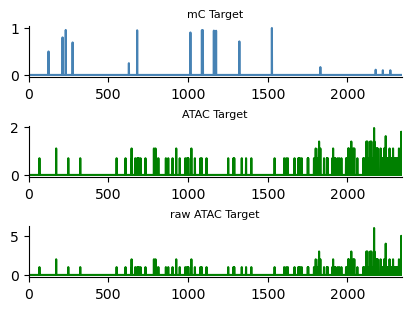

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

nrows = 3
fig = plt.figure(figsize=(4,3), dpi=100, constrained_layout=True)
gs = fig.add_gridspec(ncols=1, nrows=nrows)
axes = [fig.add_subplot(gs[i]) for i in range(nrows)]

mc_target = batch["allc_mc_frac"][1,0,:]
atac_target = batch["atac_bw_values"][1,0,:]
raw_atatc_target = raw_data

base = 0
ax = axes[base + 0]
ax.plot(mc_target, color="steelblue")
ax.set_title("mC Target", fontsize=8)

ax = axes[base + 1]
ax.plot(atac_target, color="green")
ax.set_title("ATAC Target", fontsize=8)

ax = axes[base + 2]
ax.plot(raw_atatc_target, color="green")
ax.set_title("raw ATAC Target", fontsize=8)
# Setting xlim and removing spines
for ax in axes:
    ax.set(xlim=(0, len(mc_target)))  # Adjusted to length of the target
    sns.despine(ax=ax)

# show plot
plt.show()

In [9]:
dataset = mcatac_dataset._get_region_cropper(dataset)
dataset = mcatac_dataset._filter_regions(dataset=dataset, cov_func=_cov_func)
dataset.schema()    

2024-08-15 22:13:23,930	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-15_22-12-42_113691_4137831/logs/ray-data
2024-08-15 22:13:23,930	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> ActorPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(CropLastAxisWithJitter)->MapBatches(FilterRegions)] -> LimitOperator[limit=1]


Column          Type
------          ----
region          string
dna_one_hot     numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc         numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov        numpy.ndarray(shape=(3, 1000), dtype=float)
allc_mc_frac    numpy.ndarray(shape=(3, 1000), dtype=float)
atac_bw_values  numpy.ndarray(shape=(1, 1000), dtype=float)
jitter          numpy.ndarray(shape=(1,), dtype=float)

In [68]:
# sanity check for mC
row_id = 1
batch = dataset.take_batch(3)

chrom, coords = batch['region'][row_id].split(':')
start, end = map(int, coords.split('-'))
jitter = batch['jitter'][row_id][0]
print(chrom, start, end, jitter)

#get cropped region
_input_center = (start + end) // 2
_output_radius = 500
new_start = _input_center - _output_radius + jitter
new_end = new_start + 1000
print(chrom, new_start, new_end)

mc_value = batch["allc_mc_frac"][row_id,0,:]
mc_index = np.where(mc_value != 0)[0] # return index where mc_value is not 0
print(mc_index)

with pysam.TabixFile(mc_allc_path) as allc:
    data = []
    for row in allc.fetch(chrom, new_start, new_end):
        data.append(row.strip().split('\t'))
region_allc_raw = pd.DataFrame(data)

region_allc_raw

2024-08-14 15:32:30,857	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-14_14-07-39_459566_1128185/logs/ray-data
2024-08-14 15:32:30,858	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> ActorPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(CropLastAxisWithJitter)->MapBatches(FilterRegions)] -> LimitOperator[limit=3]


chr1 824902 827242 17.0
chr1 825589.0 826589.0
[328 400 406 475 489 635 839]


[W::hts_idx_load3] The index file is older than the data file: /large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/allc/ASC_0.CGN-Merge.allc.tsv.gz.tbi


,0,1,2,3,4,5,6
0,chr1,825918,+,CGG,19,21,1
1,chr1,825990,+,CGA,21,22,1
2,chr1,825996,+,CGG,21,22,1
3,chr1,826065,+,CGA,17,18,1
4,chr1,826079,+,CGG,16,17,1
5,chr1,826225,+,CGT,10,14,1
6,chr1,826429,+,CGT,1,1,1


In [69]:
mc_value[mc_index] 

array([0.90476185, 0.9545454 , 0.9545454 , 0.94444436, 0.94117635,
       0.7142857 , 0.99999905], dtype=float32)

In [70]:
# sanity check for ATAC bigwig
print(chrom, new_start, new_end)
with pyBigWig.open(atac_bw_path) as bw:
    print(chrom, start, end)
    raw_data = np.nan_to_num(bw.values(chrom, int(new_start), int(new_end), numpy=True))

print(raw_data.sum())
log_data = np.log1p(raw_data)
print(log_data.sum())

chr1 825589.0 826589.0
chr1 824902 827242
37.0
24.495718


In [71]:
batch_value = batch['atac_bw_values'][row_id].ravel()
batch_value.sum()

24.495718

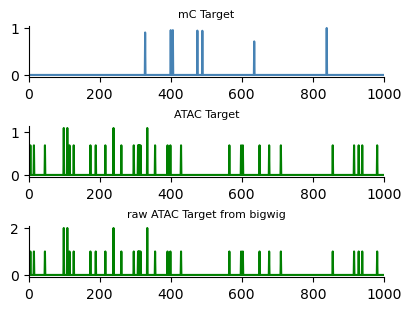

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

nrows = 3
fig = plt.figure(figsize=(4,3), dpi=100, constrained_layout=True)
gs = fig.add_gridspec(ncols=1, nrows=nrows)
axes = [fig.add_subplot(gs[i]) for i in range(nrows)]

mc_target = batch["allc_mc_frac"][row_id,0,:]
atac_target = batch["atac_bw_values"][row_id,0,:]
raw_atatc_target = raw_data

base = 0
ax = axes[base + 0]
ax.plot(mc_target, color="steelblue")
ax.set_title("mC Target", fontsize=8)

ax = axes[base + 1]
ax.plot(atac_target, color="green")
ax.set_title("ATAC Target", fontsize=8)

ax = axes[base + 2]
ax.plot(raw_atatc_target, color="green")
ax.set_title("raw ATAC Target from bigwig", fontsize=8)
# Setting xlim and removing spines
for ax in axes:
    ax.set(xlim=(0, len(mc_target)))  # Adjusted to length of the target
    sns.despine(ax=ax)

# show plot
plt.show()

In [10]:
dataset = mcatac_dataset._get_reverse_complement_region(dataset)
dataset.schema()

2024-08-15 15:43:37,927	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-15_15-42-19_000604_2550921/logs/ray-data
2024-08-15 15:43:37,928	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> ActorPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(CropLastAxisWithJitter)->MapBatches(FilterRegions)] -> TaskPoolMapOperator[MapBatches(ReverseComplement)] -> LimitOperator[limit=1]


Column          Type
------          ----
region          string
dna_one_hot     numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc         numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov        numpy.ndarray(shape=(3, 1000), dtype=float)
allc_mc_frac    numpy.ndarray(shape=(3, 1000), dtype=float)
atac_bw_values  numpy.ndarray(shape=(1, 1000), dtype=float)
jitter          numpy.ndarray(shape=(1,), dtype=float)

In [75]:
# sanity check for mC
row_id = 1
batch = dataset.take_batch(3)

chrom, coords = batch['region'][row_id].split(':')
start, end = map(int, coords.split('-'))
jitter = batch['jitter'][row_id][0]
print(chrom, start, end, jitter)

#get cropped region
_input_center = (start + end) // 2
_output_radius = 500
new_start = _input_center - _output_radius + jitter
new_end = new_start + 1000
print(chrom, new_start, new_end)

mc_value = batch["allc_mc_frac"][row_id,0,:]
mc_index = np.where(mc_value != 0)[0] # return index where mc_value is not 0
print(mc_index)
print(mc_value[mc_index])

with pysam.TabixFile(mc_allc_path) as allc:
    data = []
    for row in allc.fetch(chrom, new_start, new_end):
        data.append(row.strip().split('\t'))
region_allc_raw = pd.DataFrame(data)

region_allc_raw

2024-08-14 15:41:19,817	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-14_14-07-39_459566_1128185/logs/ray-data
2024-08-14 15:41:19,817	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> ActorPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(CropLastAxisWithJitter)->MapBatches(FilterRegions)] -> TaskPoolMapOperator[MapBatches(ReverseComplement)] -> LimitOperator[limit=3]


chr1 824902 827242 -82.0
chr1 825490.0 826490.0
[ 41  93 427 499 505 574 588 734 938]
[0.24999999 0.9512195  0.90476185 0.9545454  0.9545454  0.94444436
 0.94117635 0.7142857  0.99999905]


[W::hts_idx_load3] The index file is older than the data file: /large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/allc/ASC_0.CGN-Merge.allc.tsv.gz.tbi


,0,1,2,3,4,5,6
0,chr1,825532,+,CGT,3,12,1
1,chr1,825584,+,CGT,39,41,1
2,chr1,825918,+,CGG,19,21,1
3,chr1,825990,+,CGA,21,22,1
4,chr1,825996,+,CGG,21,22,1
5,chr1,826065,+,CGA,17,18,1
6,chr1,826079,+,CGG,16,17,1
7,chr1,826225,+,CGT,10,14,1
8,chr1,826429,+,CGT,1,1,1


In [76]:
# sanity check for ATAC bigwig
print(chrom, new_start, new_end)
with pyBigWig.open(atac_bw_path) as bw:
    raw_data = np.nan_to_num(bw.values(chrom, int(new_start), int(new_end), numpy=True))

print(raw_data.sum())
log_data = np.log1p(raw_data)
print(log_data.sum())

batch_value = batch['atac_bw_values'][row_id].ravel()
print(batch_value.sum())

chr1 825490.0 826490.0
40.0
26.287477
26.287477


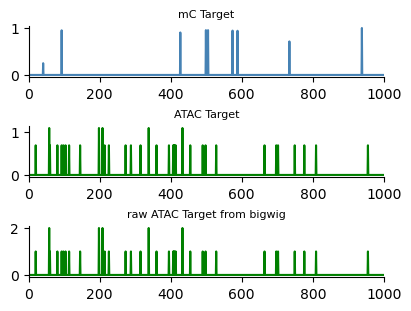

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

nrows = 3
fig = plt.figure(figsize=(4,3), dpi=100, constrained_layout=True)
gs = fig.add_gridspec(ncols=1, nrows=nrows)
axes = [fig.add_subplot(gs[i]) for i in range(nrows)]

mc_target = batch["allc_mc_frac"][row_id,0,:]
atac_target = batch["atac_bw_values"][row_id,0,:]
raw_atatc_target = raw_data

base = 0
ax = axes[base + 0]
ax.plot(mc_target, color="steelblue")
ax.set_title("mC Target", fontsize=8)

ax = axes[base + 1]
ax.plot(atac_target, color="green")
ax.set_title("ATAC Target", fontsize=8)

ax = axes[base + 2]
ax.plot(raw_atatc_target, color="green")
ax.set_title("raw ATAC Target from bigwig", fontsize=8)
# Setting xlim and removing spines
for ax in axes:
    ax.set(xlim=(0, len(mc_target)))  # Adjusted to length of the target
    sns.despine(ax=ax)

# show plot
plt.show()

2024-08-14 16:01:53,464	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-14_14-07-39_459566_1128185/logs/ray-data
2024-08-14 16:01:53,465	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> ActorPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(CropLastAxisWithJitter)->MapBatches(FilterRegions)] -> TaskPoolMapOperator[MapBatches(ReverseComplement)] -> LimitOperator[limit=5]


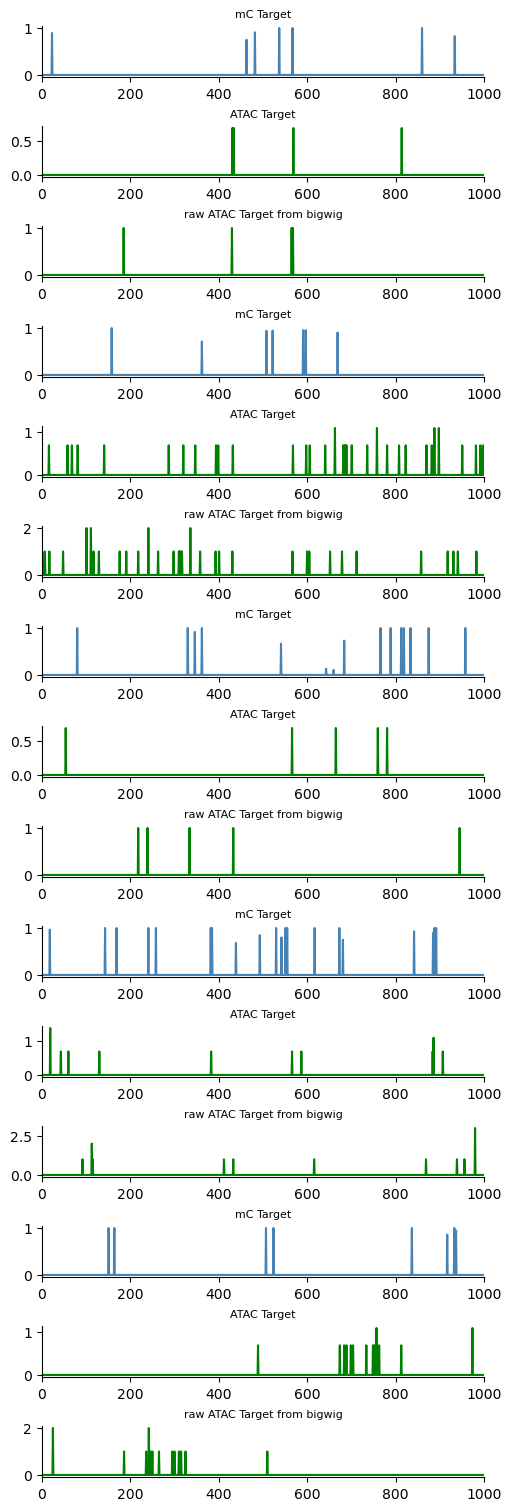

In [81]:
batch = dataset.take_batch(5)

nrows = 15
fig = plt.figure(figsize=(5,15), dpi=100, constrained_layout=True)
gs = fig.add_gridspec(ncols=1, nrows=nrows)
axes = [fig.add_subplot(gs[i]) for i in range(nrows)]

for row_id in range(5):
    mc_target = batch["allc_mc_frac"][row_id,0,:]
    atac_target = batch["atac_bw_values"][row_id,0,:]

    chrom, coords = batch['region'][row_id].split(':')
    start, end = map(int, coords.split('-'))
    jitter = batch['jitter'][row_id][0]

    #get cropped region
    _input_center = (start + end) // 2
    _output_radius = 500
    new_start = _input_center - _output_radius + jitter
    new_end = new_start + 1000
    with pyBigWig.open(atac_bw_path) as bw:
        raw_data = np.nan_to_num(bw.values(chrom, int(new_start), int(new_end), numpy=True))
    raw_atatc_target = raw_data

    ax = axes[3*row_id + 0]
    ax.plot(mc_target, color="steelblue")
    ax.set_title("mC Target", fontsize=8)

    ax = axes[3*row_id + 1]
    ax.plot(atac_target, color="green")
    ax.set_title("ATAC Target", fontsize=8)

    ax = axes[3*row_id + 2]
    ax.plot(raw_atatc_target, color="green")
    ax.set_title("raw ATAC Target from bigwig", fontsize=8)
# Setting xlim and removing spines
for ax in axes:
    ax.set(xlim=(0, len(mc_target)))  # Adjusted to length of the target
    sns.despine(ax=ax)

# show plot
plt.show()

In [12]:
batch = dataset.take_batch(64)
dataset.schema()

2024-08-15 13:08:40,640	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-15_12-57-29_678915_1831256/logs/ray-data
2024-08-15 13:08:40,641	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> ActorPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(CropLastAxisWithJitter)->MapBatches(FilterRegions)] -> LimitOperator[limit=64]


Column          Type
------          ----
region          string
dna_one_hot     numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc         numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov        numpy.ndarray(shape=(3, 1000), dtype=float)
allc_mc_frac    numpy.ndarray(shape=(3, 1000), dtype=float)
atac_bw_values  numpy.ndarray(shape=(1, 1000), dtype=float)
jitter          numpy.ndarray(shape=(1,), dtype=float)

In [29]:
### mc-filtered dataset
hypo_cutoff = 0.8
hyper_ratio = 0.2

mc_frac = batch["allc_mc_frac"][:,0,:]
# row_sel_bool: bool array, shape: [batch_size]
row_sel_bool = np.any((mc_frac > 0.1) & (mc_frac < 0.8), axis=1)  # Hypo-mC condition
print(row_sel_bool)

false_indices = np.where(row_sel_bool == False)[0]

# Randomly select indices of the False values to change
indices_to_change = np.random.choice(false_indices, len(false_indices) // 2, replace=False)

# Set the selected False values to True
row_sel_bool[indices_to_change] = True

print(row_sel_bool)

new_dict = {k: v[row_sel_bool] for k, v in batch.items()}

[ True  True  True  True False  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True  True  True  True  True  True
  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True  True  True  True  True  True
  True  True  True  True]


In [12]:
dataset = mcatac_dataset._mc_frac_filter(dataset)
dataset.schema()

2024-08-15 15:45:08,460	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-15_15-42-19_000604_2550921/logs/ray-data
2024-08-15 15:45:08,461	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(_mc_frac)->MapBatches(FetchRegionBigWigs)] -> ActorPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(CropLastAxisWithJitter)->MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(ReverseComplement)->MapBatches(FilterBymCFrac)] -> ActorPoolMapOperator[MapBatches(FilterBymCFrac)] -> LimitOperator[limit=1]


Column          Type
------          ----
region          string
dna_one_hot     numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc         numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov        numpy.ndarray(shape=(3, 1000), dtype=float)
allc_mc_frac    numpy.ndarray(shape=(3, 1000), dtype=float)
atac_bw_values  numpy.ndarray(shape=(1, 1000), dtype=float)
jitter          numpy.ndarray(shape=(1,), dtype=float)

In [15]:
# batch = dataset.take_batch(64)

region = batch["region"]
jitter = batch["jitter"]
regions_array = np.empty((len(region), 3), dtype=int)
for i, r in enumerate(region):
    chrom, coords = r.split(':')
    chrom = chrom.split('chr')[1]
    start, end = map(int, coords.split('-'))
    center = (start + end) // 2
    _start = center - 500 + jitter[i][0]
    _end = 1000 + _start
    regions_array[i] = [chrom, _start, _end]

print(regions_array.shape)
batch["final_region"] = regions_array

(64, 3)
